# Generating Neutral Redistricting Maps for Utah

Welcome! This project is designed to empower you to explore fair and neutral possibilities for Utah's electoral districts. We will be using a method called ensemble analysis to generate thousands of potential district maps that all follow a consistent set of neutral rules based on Utah's Proposition 4.

In this notebook, we will develop a set of rules and instructions to guide the computer in drawing maps, drawing a sample of maps and confirming the algorithm is satisfying the neutral standards to your liking. Then we'll import your configuration into the large scale environment for full ensemble analysis of Utah's redistricting requirements, including its prohibition on partisan gerrymandering.

## What Is an Ensemble and Why Is It Useful?

It's impossible to find the single "best" or "fairest" map. Instead, we can generate a large collection of maps called an __ensemble__ that all comply with a given set of legal and community-based criteria.

Think of it like this: if you ask 10,000 different people to draw a "fair" map, you could get up to 10,000 different valid maps. Some of them might be quite unique, while others could even be identical, but together they represent a general distribution of what fair maps look like. By studying this entire collection, we can understand the _range_ of possible outcomes. If an officially proposed or enacted map looks very different from the vast majority of maps in our neutral ensemble, it might be an outlier worth scrutinizing.

To create this ensemble, we will use a technique called a __Markov Chain Monte Carlo (MCMC)__ simulation. Specifically, we use a method called __Recombination (ReCom)__, which is designed to explore a wide variety of map configurations efficiently. In simple terms, our program will:
1. Start with an existing map.
2. Randomly pick two neighboring districts.
3. Temporarily merge them into one large "super-district".
4. Randomly draw a new boundary within this super-district to split it back into two new, population-balanced districts.
5. Check if this newly-drawn map follows all of our other rules.
6. If it does, we add it to our collection and repeat.

By doing this thousands of times, we build a massive, diverse ensemble of valid district maps.

## Basic Settings
Choose how many maps this configuration tuning notebook will generate and how many should be rendered for visualization. Note that when you import your chosen parameters into the full ensemble runner, you will be able to set the ensemble size and render frequency there.

You can also choose a "seed" for the random number generator, so your exact ensemble can be reproduced later.

In [11]:
import os
from datetime import datetime as dt
from math import floor

from utgc import GeographyManager, ConfigurationManager, precondition, create_partition_iterator
import utgc.notebookhelper as nbh

# Configuration files and example maps will be saved to a directory with
# the current date and time plus an optional user-defined tag.
config_tag = "test"  # <-- Change this to something descriptive if desired

# Where the configuration file and all related results will be saved
config_dir = os.path.join("output", config_tag or dt.now().strftime("%Y%m%d%H%M%S"))

# Data file path – the d4-cap (census block, capped epsilon=1e-3) dataset
geo = GeographyManager(
    pop_data={"d4-cap": "data/UT_capped_d4_eps1e-3.geojson"},
    crs="EPSG:26912",
)
geo.fill_empty_ids("d4-cap", ["MUNIID"])

initial_plan = "maps/US-House/2025_USH_Leg-C/2025_USH_Leg-C.shp"
num_districts = nbh.get_district_count(initial_plan)
print(f"Number of districts: {num_districts}")

cfg = ConfigurationManager()
cfg = cfg.set_pop_column("TOTPOP")
cfg = cfg.add_pop_dev_updater()

Number of districts: 4


## Utah's Neutral Redistricting Standards

Utah law provides the following standards for how maps must be drawn, which are given an order of priority.
1. Follow the US. Constitution and federal law, maintaining equal population between districts and complying with the Voting Rights Act.
2. Minimize splitting cities and counties, with cities being most important to keep whole.
3. Make districts geographically compact.
4. Make districts contiguous and allow ease of travel throughout district
5. Preserve neighborhoods and communities of interest
6. Where possible, follow mountains, rivers, and other natural boundaries.
7. Where possible, line up the boundaries of different types of districts (e.g., Congressional and State Senate)

We have a variety of tools at our disposal to help the computer follow these rules, but how _exactly_ to balance the different priorities is a question for humans to answer.

## Select Parameters
In the sections below, you can configure different parameters to match your interpretation of the law's priorities. There's no harm in experimenting, so give it a go!

### Constraints
One way to guide map drawing is through __constraints__. When a constraint is not met, the map is rejected and the algorithm must draw new maps until it creates one that passes. 

One quick note on the not equal constraint: This constraint serves as a protection against creating sparsely sampled distributions, even if the parameters are demanding. It makes sure that each map is different than the one that came immediately before it, but does not prevent the same map from being drawn again in future steps. This helps the sampler ensure we don't get stuck in local optima while preserving the Markov condition. If we instead require that each map be unique, the resulting distribution can no longer be interpreted probabilistically and is not considered Markov chain sampling.

In [12]:
# Population deviation tolerance is passed to proposal() and precondition() directly.
# That call uses pop_tolerance=0.001 (0.1%). No separate set_pop_dev_tolerance method.
cfg = (cfg
    # How can municipalities be split?
    .constrain_region_splits(
        name="muni",
        column_id="MUNIID",
        # How many municipalities can be split total?
        num_split=floor(num_districts / 2),
        # How many splits past the first for each muni are allowed (map wide)?
        num_multi_splits=floor(num_districts / 6),
    )
    # How can counties be split?
    .constrain_region_splits(
        name="county",
        column_id="COUNTYID",
        # How many counties can be split total?
        num_split=round(num_districts / 2) + 1,
        # How many splits past the first for each county are allowed (map wide)?
        num_multi_splits=floor(num_districts / 5),
    )
    # Whether to prevent the algorithm from drawing the same map twice in a row
    .constrain_not_equal(not_equal_constraint=True)
)

### Region Surcharges and Edge Penalties
A __region surcharge__ adjusts the probability that the algorithm will draw a line that cuts through a region of that type, with _higher_ values making it _less_ likely to be split. Using all zeros would allow the algorithm to draw lines with uniform probablity--leaving it very free to explore, but potentially very bad at meeting constraints or honoring that particular criterion. On the other hand, large values help encourage keeping that region type intact (and meeting any related constraints). If a surcharge is too large, however, it can dramatically limit the space of maps that are possible to explore, and the algorithm might draw the same map many times. 

Similarly, __edge penalties__ can decrease the probability of crossing certain borders in forming a district, such as to discourage creating a district that would not be transitable in real life. The scale of edge penalties is the same as for region surcharges, so the relative importance of each should reflect the order of priority from the neutral standards.

In [13]:
cfg = (cfg
    ### Region surcharge configuration ###
    # Municipalities
    .surcharge_region(column_id="MUNIID", surcharge=1)
    # Counties
    .surcharge_region(column_id="COUNTYID", surcharge=0.8)
    # Institutions of higher education
    .surcharge_region(column_id="HIGHEREDID", surcharge=0.2)
    # Indian Reservations (American Indian / Alaska Native Areas)
    .surcharge_region(column_id="AIANNHID", surcharge=0.2)
    # Military Installations
    .surcharge_region(column_id="MILITID", surcharge=0.2)
    # Metro/micropolitan areas (CBSA – Core Based Statistical Areas)
    .surcharge_region(column_id="CBSAID", surcharge=0.1)

    ### Edge penalty configuration ###
    # Transitability
    # .penalize_edges_from_csv(
    #     csv_path="data/UT_blocks_transitability.csv",
    #     penalty=0.3,
    # )
)

### Tilted Run
The last way to influence the map drawing process is through a __optimizer__. During a optimizer run, the algorithm scores each map on some criterion. This score is used to influence subsequent updates in some way.

* Using the `short_bursts` optimizer, each iteration is free to draw any map that meets the constraints. At the end of every burst period (for example, 10 steps), the starting point is reset to the map that had the best score.
* in a `tilted_run` If a map scores better than the one before it, the map is accepted. If the map scores worse, there is some probability that the map will be rejected.

These techniques can encourage the ensemble generally to sample maps that perform well on that score, without enforcing it strictly. Here, we can use it to encourage compact districts.

In [14]:
cfg = (cfg
    .add_shape_metrics(["polsby_popper"])
    # .add_optimization_scheme(
    #     scheme='short_bursts',
    #     updater='polsby_popper',
    #     burst_length=10,
    #     maximize=True,
    # )
)

## Preconditioning
Before running the ensemble, we'll run a several iterations of optimization to make sure our starting point fulfills all the constraints we've set. If the algoritm is struggling to run successful preconditioning, that's a sign that our constraints and surcharges might not be working together well--or that a constraint is simply too strict for the underlying geography.

In [15]:
print("=== Preconditioning ===")

initial_partition = geo.build_partition(
    pop_key="d4-cap",
    plan=initial_plan,
    updaters=cfg.updaters,
)
total_pop = sum(initial_partition["population"].values())
pop_tolerance = 0.001

proposal = cfg.proposal(
    initial_partition,
    total_population=total_pop,
    pop_tolerance=pop_tolerance,
)

initial_partition = precondition(
    initial_partition=initial_partition,
    proposal=proposal,
    constraints=cfg.constraints,
    constraint_params=cfg.get_constraint_params(),
    population_params={
        "ideal_pop": total_pop / num_districts,
        "pop_tolerance": pop_tolerance,
    },
    graph=geo.get_graph("d4-cap"),
    updaters=cfg.updaters,
    steps=25,
    max_attempts=1,
)

=== Preconditioning ===
Starting preconditioning...


100%|██████████| 25/25 [02:30<00:00,  6.02s/it]

  Preconditioning successful! All tolerances met.


In [16]:
import json
import utgc.plotting as gcplt

munis, counties = nbh.load_boundaries_from_shapefiles()

run_name = "testrun"
save_dir = os.path.join(config_dir, run_name)
os.makedirs(os.path.join(save_dir, "maps"), exist_ok=True)
cfg.to_config(os.path.join(save_dir, "config.yaml"))

# Serializable, analysis-relevant updaters to write to output.jsonl.
# Excludes intermediates such as population, pop_dev, perimeter, area,
# ls_muni, ls_county, raw election updaters, sb1011_data_table, etc.
output_updaters = {
    "split_muni", "split_county", "muni_multi_splits", "county_multi_splits",
    "assignment_hash", "polsby_popper",
}
print(f"Output will be saved to {save_dir}")

Loaded 29 counties from data/bounds/UtahCountyBoundaries/ut_cnty_2020_bound.shp
Loaded 259 municipalities from data/bounds/UtahMunicipalBoundaries/Municipalities.shp
Output will be saved to output/test/testrun


In [17]:
num_steps = 50
proposal = cfg.proposal(
    initial_partition,
    total_population=total_pop,
    pop_tolerance=pop_tolerance,
)
partition_iterator = create_partition_iterator(
    proposal=proposal,
    initial_partition=initial_partition,
    constraints=cfg.constraints,
    optimization_scheme_params={"scheme": "neutral"},
    num_steps=num_steps,
)

print(f"=== MCMC {run_name} ===")
print("Running Markov chain...")
output_path = os.path.join(save_dir, "output.jsonl")
assignments_path = os.path.join(save_dir, "assignments.jsonl")
with open(output_path, "w") as f, open(assignments_path, "w") as af:
    for step_number, partition in enumerate(partition_iterator, 1):
        # Save metrics (output_updaters subset only)
        data = {"step": step_number}
        for name in output_updaters:
            if name not in cfg.updaters:
                continue
            value = partition[name]
            if isinstance(value, dict):
                data[name] = {str(k): v for k, v in sorted(value.items())}
            else:
                data[name] = value
        f.write(json.dumps(data) + "\n")
        f.flush()
        # Save district assignment
        af.write(json.dumps({
            "step": step_number,
            "assignment": {str(k): int(v) for k, v in partition.assignment.items()},
        }) + "\n")
        af.flush()
        # Render map every step (frequency=1 for configure notebook)
        gcplt.visualize_partition(
            partition, step_number, os.path.join(save_dir, "maps"),
            counties=counties, municipalities=munis,
            split_munis_count=partition["split_muni"],
            split_counties_count=partition["split_county"],
        )
        partition.parent = None
print("Done.")

  0%|          | 0/50 [00:00<?, ?it/s]

Configured neutral run with 50 steps
=== MCMC testrun ===
Running Markov chain...
Done.


In [18]:
nbh.map_viewer_widget(os.path.join(config_dir, "testrun/maps"))

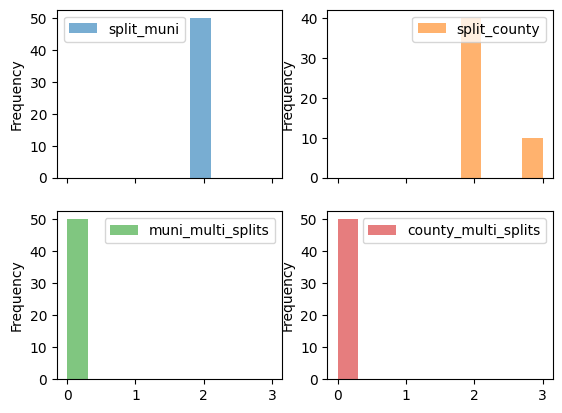

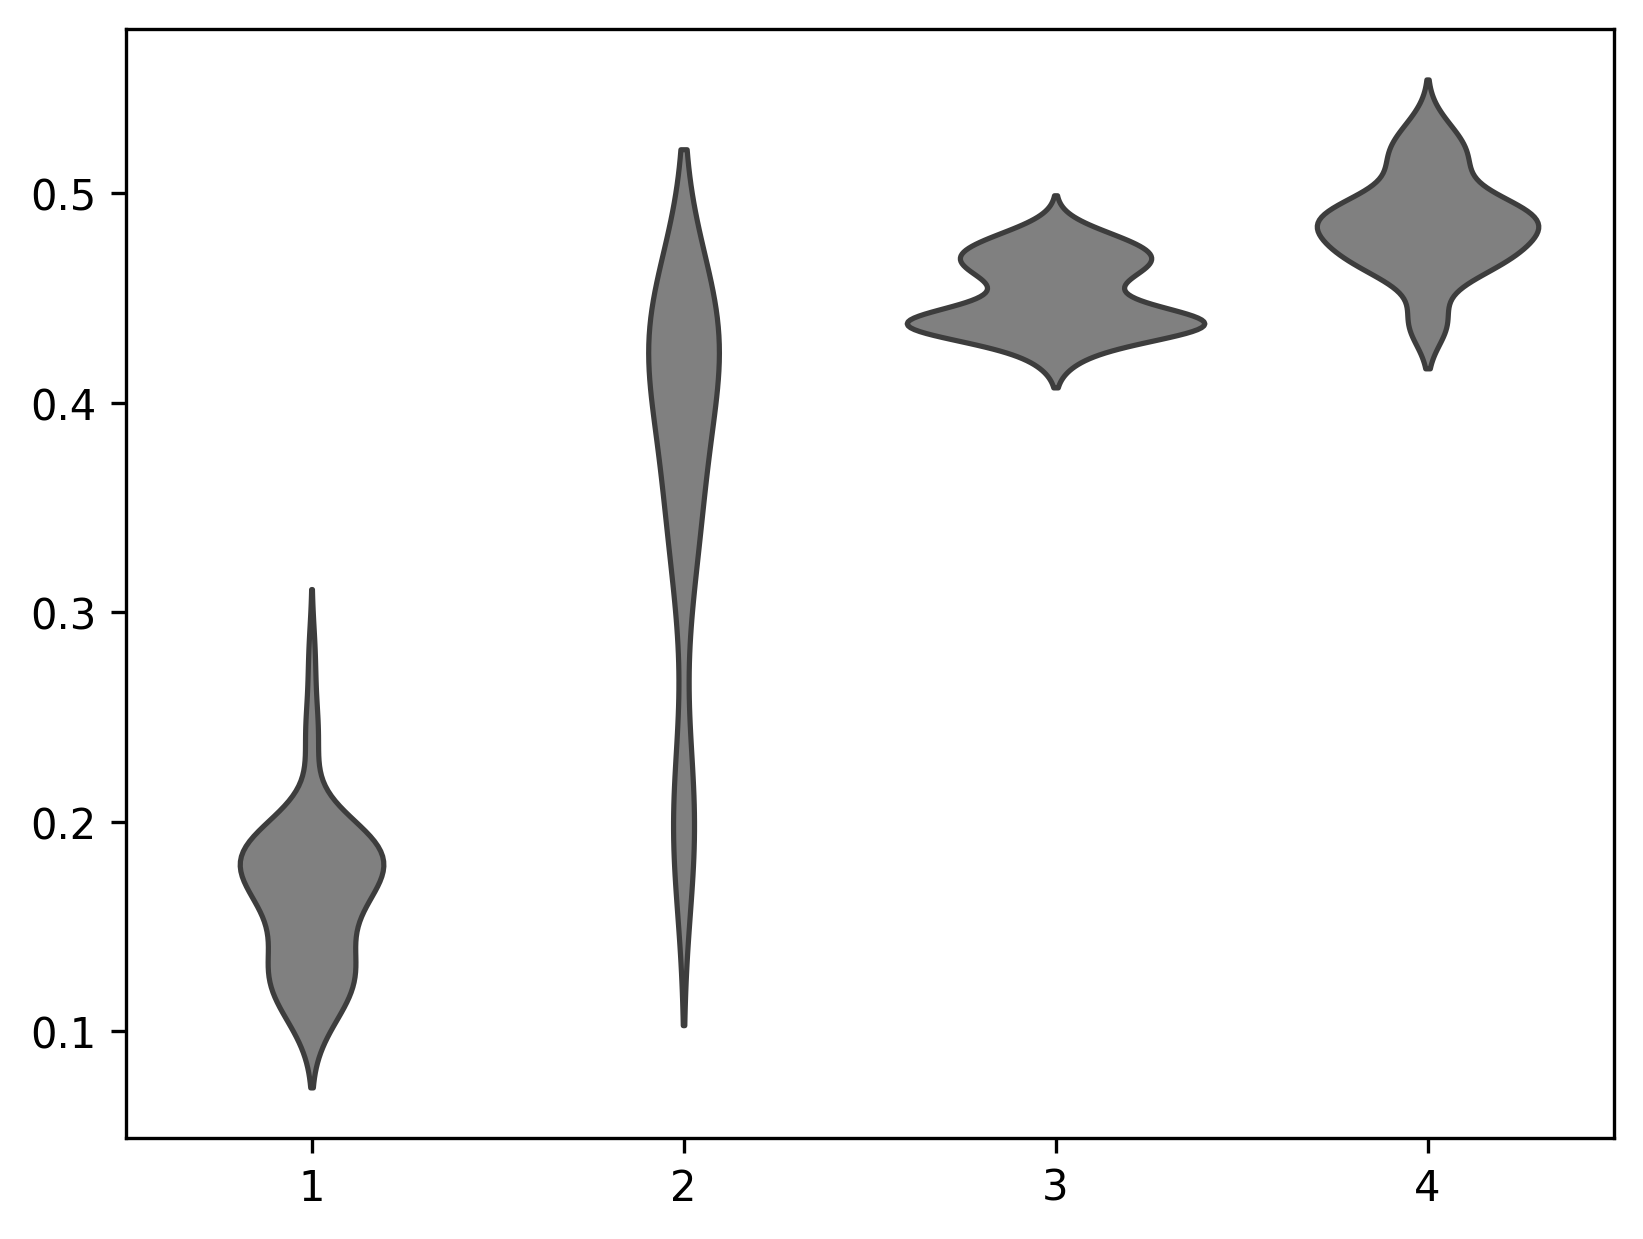

In [19]:
import utgc.results as gcres
import matplotlib.pyplot as plt

output_path = os.path.join(config_dir, "testrun/output.jsonl")

splits = gcres.read_jsonl_table(
    output_path, ["split_muni", "split_county", "muni_multi_splits", "county_multi_splits"]
)
compactness = gcres.read_jsonl_table(output_path, "polsby_popper")
compactness = gcres.sort_subentries(compactness, "polsby_popper")

# Histogram for each column in the splits dataframe
splits.plot.hist(alpha=0.6, subplots=True, layout=(2, 2))
plt.show()

plt.figure(dpi=300)
gcplt.district_plot(compactness, relative_to_median=False)
plt.show()

In [20]:
hashes = gcres.read_jsonl_table(output_path, "assignment_hash")
print(f"Unique maps: {len(hashes.drop_duplicates()) / len(hashes):.1%}")

Unique maps: 100.0%
